In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv("C:/Users/diego/Desktop/Seguidor.csv")

print("===================================")
print("INFORMACION GENERAL DEL DATASET")
print("===================================")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

INFORMACION GENERAL DEL DATASET
Filas: 586
Columnas: 13

Columnas:
['hora', 'test', 's0', 's1', 's2', 's3', 'error', 'corr', 'left', 'right', 'kp', 'kd', 'estado']

Primeras filas:


,hora,test,s0,s1,s2,s3,error,corr,left,right,kp,kd,estado
0,11:59:36,1,916,33,18,143,0.75,0.03,179,180,0.03,0.02,centrado
1,11:59:36,1,942,27,23,23,2.77,0.09,179,180,0.03,0.02,vuelta_derecha
2,11:59:36,1,55,855,843,24,0.88,0.02,179,180,0.03,0.02,desviado
3,11:59:36,1,36,43,597,38,0.00,0.00,-40,200,0.03,0.02,recuperacion
4,11:59:37,1,39,47,431,72,0.00,0.00,-40,200,0.03,0.02,recuperacion


In [4]:
# TIPOS DE DATOS

print("\n===================================")
print("TIPOS DE DATOS")
print("===================================")

print(df.dtypes)

# ==========================================
# VALORES FALTANTES
# ==========================================

print("\n===================================")
print("VALORES FALTANTES")
print("===================================")

nulos = df.isnull().sum()

display(pd.DataFrame({
    "Variable": nulos.index,
    "Valores Nulos": nulos.values
}))

print(f"\nTotal de valores nulos: {nulos.sum()}")



TIPOS DE DATOS
hora          str
test        int64
s0          int64
s1          int64
s2          int64
s3          int64
error     float64
corr      float64
left        int64
right       int64
kp        float64
kd        float64
estado        str
dtype: object

VALORES FALTANTES


,Variable,Valores Nulos
0,hora,0
1,test,0
2,s0,0
3,s1,0
4,s2,0
5,s3,0
6,error,0
7,corr,0
8,left,0
9,right,0



Total de valores nulos: 0


In [17]:
# REGISTROS DUPLICADOS

print("\n===================================")
print("REGISTROS DUPLICADOS")
print("===================================")

duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")


# ESTADISTICAS DESCRIPTIVAS


print("\n===================================")
print("ESTADISTICAS DESCRIPTIVAS")
print("===================================")

display(df.describe())


REGISTROS DUPLICADOS
Registros duplicados encontrados: 0

ESTADISTICAS DESCRIPTIVAS


,test,s0,s1,s2,s3,error,corr,left,right,kp,kd
count,586.0,586.000000,586.000000,586.000000,586.000000,586.000000,586.000000,586.000000,586.000000,5.860000e+02,5.860000e+02
mean,1.0,276.901024,288.054608,230.440273,139.906143,0.643157,0.019539,168.822526,117.887372,3.000000e-02,2.000000e-02
std,0.0,353.566624,343.407202,337.365607,164.801097,1.163601,0.036570,60.259234,100.736795,3.472411e-18,3.472411e-18
min,1.0,0.000000,0.000000,0.000000,0.000000,-2.790000,-0.090000,-40.000000,-40.000000,3.000000e-02,2.000000e-02
25%,1.0,37.000000,34.000000,25.000000,45.000000,0.000000,0.000000,179.000000,-40.000000,3.000000e-02,2.000000e-02
50%,1.0,60.000000,63.500000,31.000000,95.000000,0.000000,0.010000,179.000000,180.000000,3.000000e-02,2.000000e-02
75%,1.0,519.000000,652.500000,442.500000,174.000000,1.317500,0.040000,200.000000,180.000000,3.000000e-02,2.000000e-02
max,1.0,982.000000,911.000000,955.000000,944.000000,3.000000,0.090000,200.000000,200.000000,3.000000e-02,2.000000e-02



DISTRIBUCION DE ESTADOS


estado
recuperacion        213
desviado            189
centrado            104
vuelta_derecha       73
vuelta_izquierda      7
Name: count, dtype: int64

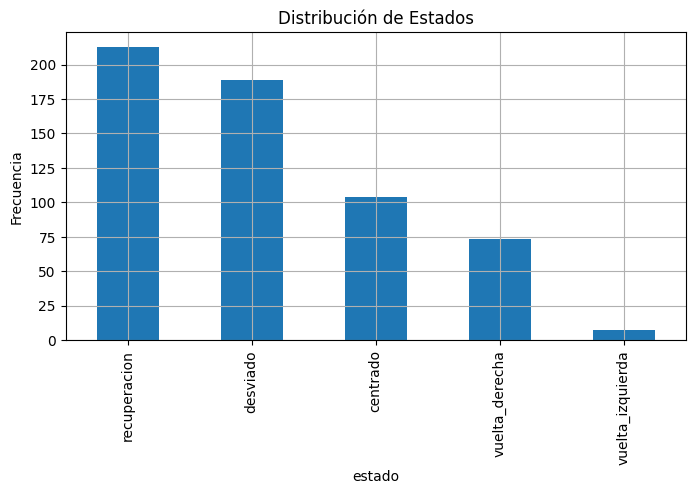

In [7]:
# ANALISIS DE LA VARIABLE ESTADO

if "estado" in df.columns:

    print("\n===================================")
    print("DISTRIBUCION DE ESTADOS")
    print("===================================")

    estados = df["estado"].value_counts()

    display(estados)

    plt.figure(figsize=(8,4))
    estados.plot(kind="bar")
    plt.title("Distribución de Estados")
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()


HISTOGRAMAS


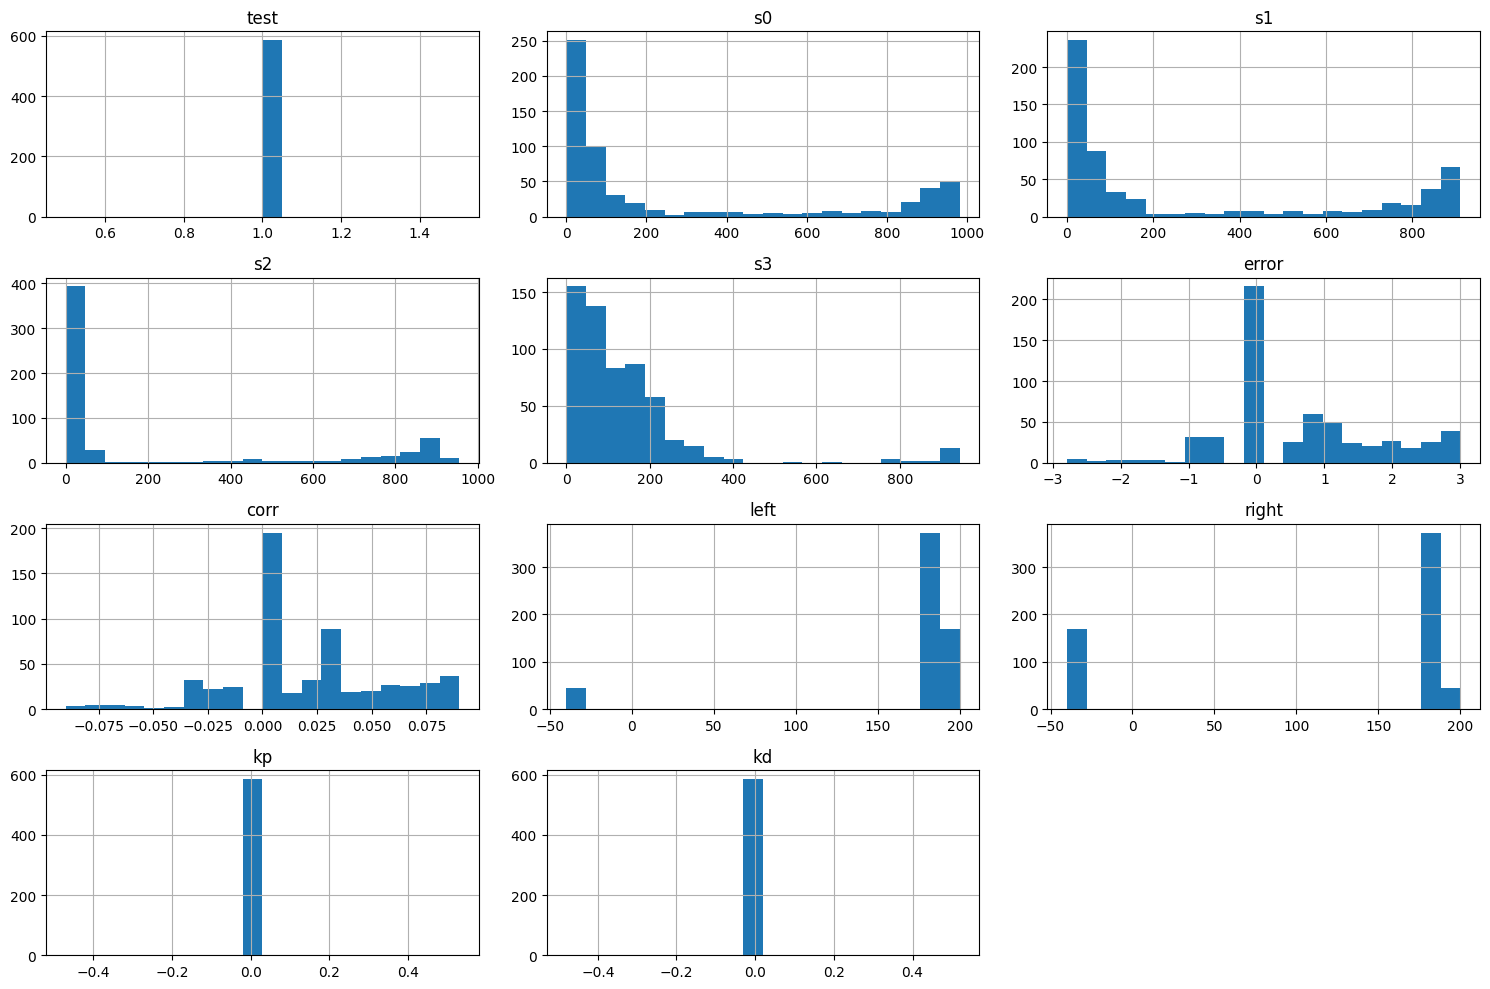

In [8]:
# HISTOGRAMAS DE VARIABLES NUMERICAS

print("\n===================================")
print("HISTOGRAMAS")
print("===================================")

columnas_numericas = df.select_dtypes(include=np.number).columns

df[columnas_numericas].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

In [9]:
# DETECCION DE OUTLIERS (IQR)


print("\n===================================")
print("DETECCION DE OUTLIERS")
print("===================================")

for col in columnas_numericas:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ]

    print(f"{col}: {len(outliers)} outliers")


DETECCION DE OUTLIERS
test: 0 outliers
s0: 0 outliers
s1: 0 outliers
s2: 0 outliers
s3: 26 outliers
error: 10 outliers
corr: 11 outliers
left: 44 outliers
right: 0 outliers
kp: 0 outliers
kd: 0 outliers


In [18]:
# CONCLUSION AUTOMATICA

print("\n===================================")
print("CONCLUSION DEL CONTROL DE CALIDAD")
print("===================================")

if nulos.sum() == 0:
    print("✓ No existen valores faltantes.")
else:
    print("⚠ Existen valores faltantes.")

if duplicados == 0:
    print("✓ No existen registros duplicados.")
else:
    print(f"⚠ Existen {duplicados} registros duplicados.")

print("✓ El dataset fue analizado correctamente.")
print("✓ Está listo para las etapas de preprocesamiento y entrenamiento del modelo.")
# TABLA RESUMEN DEL DATASET
# ==========================================

print("===================================")
print("RESUMEN DEL DATASET")
print("===================================")

resumen = pd.DataFrame({
    "Indicador": [
        "Numero de muestras",
        "Numero de variables",
        "Numero de pruebas",
        "Numero de estados"
    ],
    "Valor": [
        len(df),
        len(df.columns),
        df["test"].nunique(),
        df["estado"].nunique()
    ]
})

display(resumen)


CONCLUSION DEL CONTROL DE CALIDAD
✓ No existen valores faltantes.
✓ No existen registros duplicados.
✓ El dataset fue analizado correctamente.
✓ Está listo para las etapas de preprocesamiento y entrenamiento del modelo.
RESUMEN DEL DATASET


,Indicador,Valor
0,Numero de muestras,586
1,Numero de variables,13
2,Numero de pruebas,1
3,Numero de estados,5


In [14]:
#DESCRIPCION DEL DATASET
# ==========================================

import pandas as pd

df = pd.read_csv("C:/Users/diego/Desktop/Seguidor.csv")

print("===================================")
print("VARIABLES REGISTRADAS Y UNIDADES")
print("===================================")

variables = pd.DataFrame({
    "Variable": [
        "hora",
        "test",
        "s0",
        "s1",
        "s2",
        "s3",
        "error",
        "corr",
        "left",
        "right",
        "kp",
        "kd",
        "estado"
    ],
    "Descripcion": [
        "Hora de captura",
        "Identificador de prueba",
        "Sensor infrarrojo izquierdo exterior",
        "Sensor infrarrojo izquierdo interior",
        "Sensor infrarrojo derecho interior",
        "Sensor infrarrojo derecho exterior",
        "Error de posicion respecto a la linea",
        "Correccion calculada por el controlador PD",
        "Velocidad motor izquierdo",
        "Velocidad motor derecho",
        "Ganancia proporcional",
        "Ganancia derivativa",
        "Estado operativo del robot"
    ],
    "Unidad": [
        "hh:mm:ss",
        "Int",
        "ADC",
        "ADC",
        "ADC",
        "ADC",
        "Float",
        "PWM",
        "PWM",
        "PWM",
        "Float",
        "Float",
        "String"
    ]
})

display(variables)
#

VARIABLES REGISTRADAS Y UNIDADES


,Variable,Descripcion,Unidad
0,hora,Hora de captura,hh:mm:ss
1,test,Identificador de prueba,Int
2,s0,Sensor infrarrojo izquierdo exterior,ADC
3,s1,Sensor infrarrojo izquierdo interior,ADC
4,s2,Sensor infrarrojo derecho interior,ADC
5,s3,Sensor infrarrojo derecho exterior,ADC
6,error,Error de posicion respecto a la linea,Float
7,corr,Correccion calculada por el controlador PD,PWM
8,left,Velocidad motor izquierdo,PWM
9,right,Velocidad motor derecho,PWM


In [16]:
# CLASES REGISTRADAS
# ==========================================

print("===================================")
print("ESTADOS REGISTRADOS")
print("===================================")

estados = df["estado"].value_counts().reset_index()
estados.columns = ["Estado", "Frecuencia"]

display(estados)

ESTADOS REGISTRADOS


,Estado,Frecuencia
0,recuperacion,213
1,desviado,189
2,centrado,104
3,vuelta_derecha,73
4,vuelta_izquierda,7
